# Sea Turtle Data Processing and Training Workflow

This notebook contains a complete data processing and model training pipeline:
1. Data Preparation
   - Copy and organize image files
   - Convert images to PNG format
   - Generate mask annotations
2. Model Training
   - SAM model fine-tuning
   - Performance monitoring and evaluation

## Environment Setup
First, import all required libraries

In [ ]:
import os
import pandas as pd
import shutil
import cv2
import numpy as np
from pycocotools.coco import COCO
from concurrent.futures import ProcessPoolExecutor, as_completed
import torch
import monai
from tqdm import tqdm
from statistics import mean
from torch.utils.data import DataLoader
from torch.optim import Adam
import yaml

# Ensure that the required custom modules have been imported.
import src.utils as utils
from src.dataloader import DatasetSegmentation, collate_fn
from src.processor import Samprocessor
from src.segment_anything import build_sam_vit_b
from src.lora import LoRA_sam

## 1. Image file copy and organization
Ensure that the data is organized reasonably for subsequent processing.

In [ ]:
# Define the basic path
prefix_dir = '/root/turtles-data/data'
csv_path = os.path.join(prefix_dir, 'metadata_splits.csv')
images_dir = os.path.join(prefix_dir, 'images_jihe')

# Create images folder
os.makedirs(images_dir, exist_ok=True)

# Read CSV file
df = pd.read_csv(csv_path)


if 'file_name' not in df.columns:
    raise ValueError("CSV文件必须包含'file_name'列")

# Get all file_name and copy pictures.
file_names = df['file_name'].tolist()
total_files = len(file_names)
print(f"Total images to copy: {total_files}")

for idx, file_name in enumerate(file_names, 1):
    src_path = os.path.join(prefix_dir, file_name)
    dest_path = os.path.join(images_dir, os.path.basename(file_name))
    
    if not os.path.exists(src_path):
        print(f"Source file {src_path} does not exist. Skipping.")
        continue
    
    try:
        shutil.copy(src_path, dest_path)
    except Exception as e:
        print(f"Error copying {src_path} to {dest_path}: {e}")
        continue
    
    if idx % 100 == 0 or idx == total_files:
        print(f"Copied {idx}/{total_files} images")

print("All images have been copied successfully.")

## 2. Image format conversion
Convert all images to PNG format and use multi-process to speed up processing.

In [ ]:
# Define a source folder and a destination folder.
source_folder = '/root/turtles-data/data/images_jihe'
target_folder = '/root/autodl-tmp/train/images'

# Create target folder
os.makedirs(target_folder, exist_ok=True)

# Supported picture suffixes
extensions = ('.jpg', '.jpeg', '.JPG')

def convert_image_cv(filename):
    source_path = os.path.join(source_folder, filename)
    try:
        img = cv2.imread(source_path)
        if img is None:
            raise ValueError("can not read the file.")
        base_name = os.path.splitext(filename)[0]
        target_filename = base_name + '.png'
        target_path = os.path.join(target_folder, target_filename)
        cv2.imwrite(target_path, img)
        return f"Converted: {filename} -> {target_filename}"
    except Exception as e:
        return f"Conversion failed.: {filename}. Error: {e}"

# Get all eligible files and convert them.
files = [f for f in os.listdir(source_folder) if f.endswith(extensions)]
total_files = len(files)
print(f"Totally find {total_files} picture needs to be converted.")

max_workers = os.cpu_count() or 4
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    future_to_file = {executor.submit(convert_image_cv, file): file for file in files}
    for future in as_completed(future_to_file):
        result = future.result()
        print(result)

print("Done.")

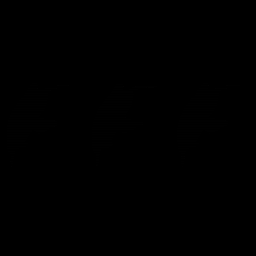

In [1]:
from IPython.display import Image, display
display(Image(filename="D:/comp9517/group_images/turtles-data/processed_data/masks/1.png"))

## 3. Generate mask label
Using COCO format label file to generate binary mask

In [ ]:
# Initialize COCO
annotations_path = '/root/turtles-data/data/annotations.json'
coco = COCO(annotations_path)

def get_binary_mask(coco, image_id):
    cat_ids = coco.getCatIds()
    ann_ids = coco.getAnnIds(imgIds=image_id, catIds=cat_ids, iscrowd=None)
    anns = coco.loadAnns(ann_ids)
    
    height = coco.imgs[image_id]['height']
    width = coco.imgs[image_id]['width']
    mask = np.zeros((height, width), dtype=np.uint8)
    
    for ann in anns:
        submask = coco.annToMask(ann)
        mask = np.maximum(mask, submask)
    
    return mask

def mask_to_rgb(mask):
    mask_rgb = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    mask_rgb[mask == 1] = [255, 255, 255]
    return mask_rgb

# Create a save directory
annotations_dir = os.path.join(prefix_dir, 'annotations')
os.makedirs(annotations_dir, exist_ok=True)

total_images = len(df)
print(f"Total images to process: {total_images}")

for idx, row in df.iterrows():
    img_id = row['id']
    file_name = row['file_name']
    fname = os.path.join(prefix_dir, file_name)
    
    if not os.path.exists(fname):
        print(f"Image file {fname} does not exist. Skipping.")
        continue
    
    try:
        mask = get_binary_mask(coco, img_id)
        mask_rgb = mask_to_rgb(mask)
        mask_filename = os.path.splitext(os.path.basename(file_name))[0] + '.png'
        mask_path = os.path.join(annotations_dir, mask_filename)
        cv2.imwrite(mask_path, cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2BGR))
    except Exception as e:
        print(f"Error processing image {file_name} (ID: {img_id}): {e}")
        continue
    
    if (idx + 1) % 100 == 0 or (idx + 1) == total_images:
        print(f"Processed {idx + 1}/{total_images} images")

print("All masks have been saved successfully.")

## 4. Model training preparation
Define auxiliary functions and configure training parameters.

In [ ]:
def print_tensor_info(tensor, name):
    """Helper function to print tensor information"""
    print(f"\n{name} info:")
    print(f"Shape: {tensor.shape}")
    print(f"Type: {tensor.dtype}")
    print(f"Unique values: {torch.unique(tensor)}")
    print(f"Range: [{tensor.min()}, {tensor.max()}]")

def calculate_iou(pred, target, smooth=1e-6):
    """Calculate IoU with correct tensor types"""
    pred = pred.bool()
    target = target.bool()
    
    intersection = (pred & target).sum().float()
    union = (pred | target).sum().float()
    
    iou = (intersection + smooth) / (union + smooth)
    return iou.item()

# Load configuration file
with open("/root/autodl-tmp/SAM-fine-tune/config.yaml", "r") as ymlfile:
    config_file = yaml.load(ymlfile, Loader=yaml.Loader)

# Category mapping
category_names = {1: "turtle", 2: "flipper", 3: "head"}

## 5. Model initialization and data loading
Prepare the model and data loader

In [ ]:
# Initialize model and data
train_dataset_path = config_file["DATASET"]["TRAIN_PATH"]
sam = build_sam_vit_b(checkpoint=config_file["SAM"]["CHECKPOINT"])
sam_lora = LoRA_sam(sam, config_file["SAM"]["RANK"])  
model = sam_lora.sam
processor = Samprocessor(model)
train_ds = DatasetSegmentation(config_file, processor, mode="train")

# Data loader
train_dataloader = DataLoader(
    train_ds, 
    batch_size=config_file["TRAIN"]["BATCH_SIZE"], 
    shuffle=True, 
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=False
)

# Optimizer and loss function
optimizer = Adam(model.image_encoder.parameters(), 
                lr=config_file["TRAIN"]["LEARNING_RATE"], 
                weight_decay=0)
seg_loss = monai.losses.DiceCELoss(sigmoid=True, 
                                   squared_pred=True, 
                                   reduction='mean')
num_epochs = config_file["TRAIN"]["NUM_EPOCHS"]

# Device settings
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model.train().to(device)

## 6. Training cycle
Perform model training and evaluation

In [ ]:
total_loss = []
best_miou = 0.0

try:
    for epoch in range(num_epochs):
        epoch_losses = []
        part_iou_scores = {1: [], 2: [], 3: []}

        for i, batch in enumerate(tqdm(train_dataloader)):
            try:
                # Forward propagation
                outputs = model(batched_input=batch, multimask_output=False)
                stk_gt, stk_out = utils.stacking_batch(batch, outputs)

                if stk_gt is None or stk_out is None:
                    continue

                # Move to devices and adjust dimensions.
                stk_gt = stk_gt.to(device)                    # Move to GPU
                stk_out = stk_out.to(device)                  # Move to GPU

                # Adjust dimension
                stk_out = stk_out.squeeze(2)                  # Remove redundant dimensions
                stk_gt = stk_gt.unsqueeze(1)                  # Add channel dimension

                # Print debugging information of the first batch.
                if i == 0:
                    print_tensor_info(stk_gt, "Ground Truth (after reshape)")
                    print_tensor_info(stk_out, "Model Output (after reshape)")
                    print(
                        f"GT shape: {stk_gt.shape}, Output shape: {stk_out.shape}")

                # Calculated loss
                loss = seg_loss(stk_out, stk_gt.float())

                # Back propagation
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # Calculate IoU
                pred_masks = (torch.sigmoid(stk_out) >
                              0.5).squeeze(1)  # Remove channel dimension for IoU calculation.
                stk_gt = stk_gt.squeeze(1)

                for part_id in part_iou_scores.keys():
                    part_gt = (stk_gt == part_id)
                    part_pred = pred_masks

                    if i < 2:  # Print the information of the first two batch.
                        print(f"\nBatch {i}, Part {part_id}:")
                        print(f"GT sum: {part_gt.sum().item()}")
                        print(f"Pred sum: {part_pred.sum().item()}")

                    try:
                        iou = calculate_iou(part_pred, part_gt)
                        part_iou_scores[part_id].append(iou)

                        if i < 2:
                            print(f"IoU: {iou}")
                    except Exception as e:
                        print(f"Error calculating IoU: {str(e)}")
                        continue

                epoch_losses.append(loss.item())

                # Monitor GPU memory
                if i % 100 == 0 and torch.cuda.is_available():
                    print(
                        f"\nGPU Memory: {torch.cuda.memory_allocated()/1024**2:.1f}MB")

            except Exception as e:
                print(f"\nError in batch {i}: {str(e)}")
                continue

        # Calculate epoch results
        if epoch_losses:
            mean_loss = mean(epoch_losses)
            print(f'\nEPOCH: {epoch}')
            print(f'Mean loss training: {mean_loss}')

            # Calculate the IoU of each part
            all_ious = []
            print("\nPer-part IoU scores:")
            for part_id, iou_list in part_iou_scores.items():
                if iou_list:
                    mean_iou = mean([x for x in iou_list if not np.isnan(x)])
                    all_ious.append(mean_iou)
                    print(f'{category_names[part_id]}: {mean_iou:.4f}')
                else:
                    print(f'{category_names[part_id]}: No valid IoU scores')

            # Calculate and save the best model.
            if all_ious:
                miou = mean(all_ious)
                print(f'\nMean IoU (mIoU): {miou:.4f}')

                if miou > best_miou:
                    best_miou = miou
                    rank = config_file["SAM"]["RANK"]
                    save_path = f"best_model_rank{rank}_miou{miou:.4f}.safetensors"
                    sam_lora.save_lora_parameters(save_path)
                    print(f"Saved new best model with mIoU: {miou:.4f}")
            else:
                print("No valid IoU scores for this epoch")

        # Clear GPU memory
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Save the final model
    rank = config_file["SAM"]["RANK"]
    sam_lora.save_lora_parameters(f"final_model_rank{rank}.safetensors")
    print(f"\nTraining completed! Best mIoU: {best_miou:.4f}")

except KeyboardInterrupt:
    print("\nTraining interrupted by user!")
    rank = config_file["SAM"]["RANK"]
    sam_lora.save_lora_parameters(f"interrupted_model_rank{rank}.safetensors")

except Exception as e:
    print(f"Training error: {str(e)}")

finally:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print(
            f"Final GPU memory: {torch.cuda.memory_allocated()/1024**2:.1f}MB")

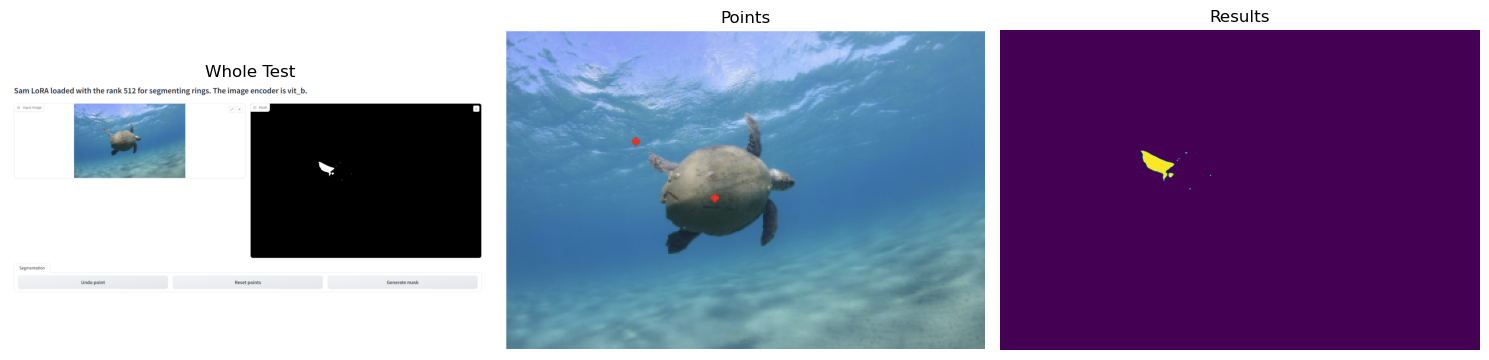

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

result_dir = "D:/comp9517/group_images/train_demo_result"

plt.figure(figsize=(15, 5))  


images = ['whole_test.png', 'points.png', 'results.png']
titles = ['Whole Test', 'Points', 'Results']

for i, (img_name, title) in enumerate(zip(images, titles)):
   plt.subplot(131 + i)  
   img = mpimg.imread(f"{result_dir}/{img_name}")
   plt.imshow(img)
   plt.title(title)
   plt.axis('off')

plt.tight_layout()  
plt.show()

For the final training test, I used a two-point approach to determine the bbox (creating a bbox using these two points), which can then differentiate the turtle parts within the bbox.

## 7. Post-training processing and evaluation
Optional model evaluation and result visualization

In [ ]:
print("Training is complete!")
print(f"The best model mIoU: {best_miou:.4f}")
print(
    f"The model is saved in: best_model_rank{config_file['SAM']['RANK']}_miou{best_miou:.4f}.safetensors")